# 教学模块一：EEG数据预处理基础
# Teaching Module 1: EEG Data Preprocessing Basics

## 课程目标

本模块分为两个主要部分：

**第一部分：Python数值处理基础**
- 学会读取CSV格式的EEG数据文件
- 掌握NumPy数组的基本操作
- 使用Matplotlib绘制时域波形
- 真正"看到"自己采集的脑电信号

**第二部分：EEG信号处理入门**
- 理解带通滤波的原理与应用（对齐项目实际使用的预处理方法）
- 掌握FFT频谱分析方法
- 观察α(8-13Hz)、β(13-30Hz)等脑电频段的特征
- 理解项目中使用的完整预处理流程

---

## 第一部分：Python数值处理基础
## Part 1: Python Numerical Processing Basics

### 1.1 导入必要的库

我们需要三个核心库：
- **NumPy**: 用于高效的数值计算和数组操作
- **Pandas**: 用于读取CSV文件
- **Matplotlib**: 用于数据可视化

In [ ]:
# ============================================================================
# 导入必要的Python库
# ============================================================================

# NumPy: 用于数值计算和数组操作，是科学计算的基础库
import numpy as np

# Pandas: 用于数据读取和处理，特别适合处理CSV等表格数据
import pandas as pd

# Matplotlib: 用于数据可视化，绘制各种图表
import matplotlib.pyplot as plt

# SciPy的signal模块: 提供信号处理工具，如滤波、FFT等
from scipy import signal

# OS模块: 用于文件和路径操作，如检查文件是否存在
import os

# ----------------------------------------------------------------------------
# 设置Matplotlib的显示参数
# ----------------------------------------------------------------------------
# figure.dpi控制图形的分辨率，100是一个适合屏幕显示的数值
plt.rcParams['figure.dpi'] = 100

# 打印导入成功信息，确认环境配置正确
print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 2.1.2
Pandas version: 2.2.3


### 1.2 读取EEG数据文件

我们的EEG数据存储在CSV文件中,每个文件包含：
- 第1列: 时间戳
- 第2-17列: 16个通道的EEG数据(CH0-CH15)

让我们读取一个实际的数据文件并查看其基本信息。

In [ ]:
# ============================================================================
# 第一步：读取EEG数据文件
# ============================================================================

# 指定要读取的CSV文件路径
# 这是一个Alert（警觉）状态下采集的脑电数据
data_file = "./dataset/train/Alert/CurveData_3_Shakespere_English_Test.csv"

# ----------------------------------------------------------------------------
# 检查文件是否存在，避免路径错误导致程序崩溃
# ----------------------------------------------------------------------------
if not os.path.exists(data_file):
    # 如果文件不存在，打印错误信息
    print(f"Error: File not found at {data_file}")
else:
    # 如果文件存在，开始读取
    print(f"Reading file: {data_file}")
    
    # ------------------------------------------------------------------------
    # 使用Pandas读取CSV文件
    # ------------------------------------------------------------------------
    # skiprows=1: 跳过第一行（CSV文件的标题行，如"Time,CH0,CH1,..."）
    # usecols=range(1, 17): 只读取第2列到第17列，共16列
    #                       第1列（索引0）是时间戳，我们暂时不需要
    #                       第2-17列（索引1-16）是16个EEG通道的数据
    eeg_data = pd.read_csv(data_file, skiprows=1, usecols=range(1, 17))
    
    # ------------------------------------------------------------------------
    # 将Pandas DataFrame转换为NumPy数组
    # ------------------------------------------------------------------------
    # NumPy数组更适合进行数值计算和信号处理
    # 转换后的形状为：(时间点数, 16个通道)
    eeg_array = eeg_data.values
    
    # ------------------------------------------------------------------------
    # 打印数据的基本信息，了解数据的结构
    # ------------------------------------------------------------------------
    print("\n=== Data Information ===")
    
    # shape属性返回数组的维度：(行数, 列数)
    # 对于EEG数据：行数=时间点数，列数=通道数
    print(f"Data shape: {eeg_array.shape}")
    
    # 第一个维度：时间点数（采样率202Hz下采集的总样本数）
    print(f"Number of time points: {eeg_array.shape[0]}")
    
    # 第二个维度：通道数（16个EEG电极）
    print(f"Number of channels: {eeg_array.shape[1]}")
    
    # 数据类型（通常是int64或float64）
    print(f"Data type: {eeg_array.dtype}")
    
    # ------------------------------------------------------------------------
    # 查看第0个通道的前5个数据点，了解数值范围
    # ------------------------------------------------------------------------
    print(f"\nFirst 5 rows of Channel 0:")
    # 使用切片操作：[:5, 0] 表示前5行，第0列
    print(eeg_array[:5, 0])

Reading file: ./dataset/train/Alert/CurveData_3_Shakespere_English_Test.csv

=== Data Information ===
Data shape: (65852, 16)
Number of time points: 65852
Number of channels: 16
Data type: int64

First 5 rows of Channel 0:
[2611842 2612349 2612424 2609848 2609437]


### 1.3 可视化原始EEG波形

现在让我们绘制EEG信号的时域波形,这是"看到"数据的第一步。

**注意**: 采样率为202Hz,意味着每秒采集202个数据点。

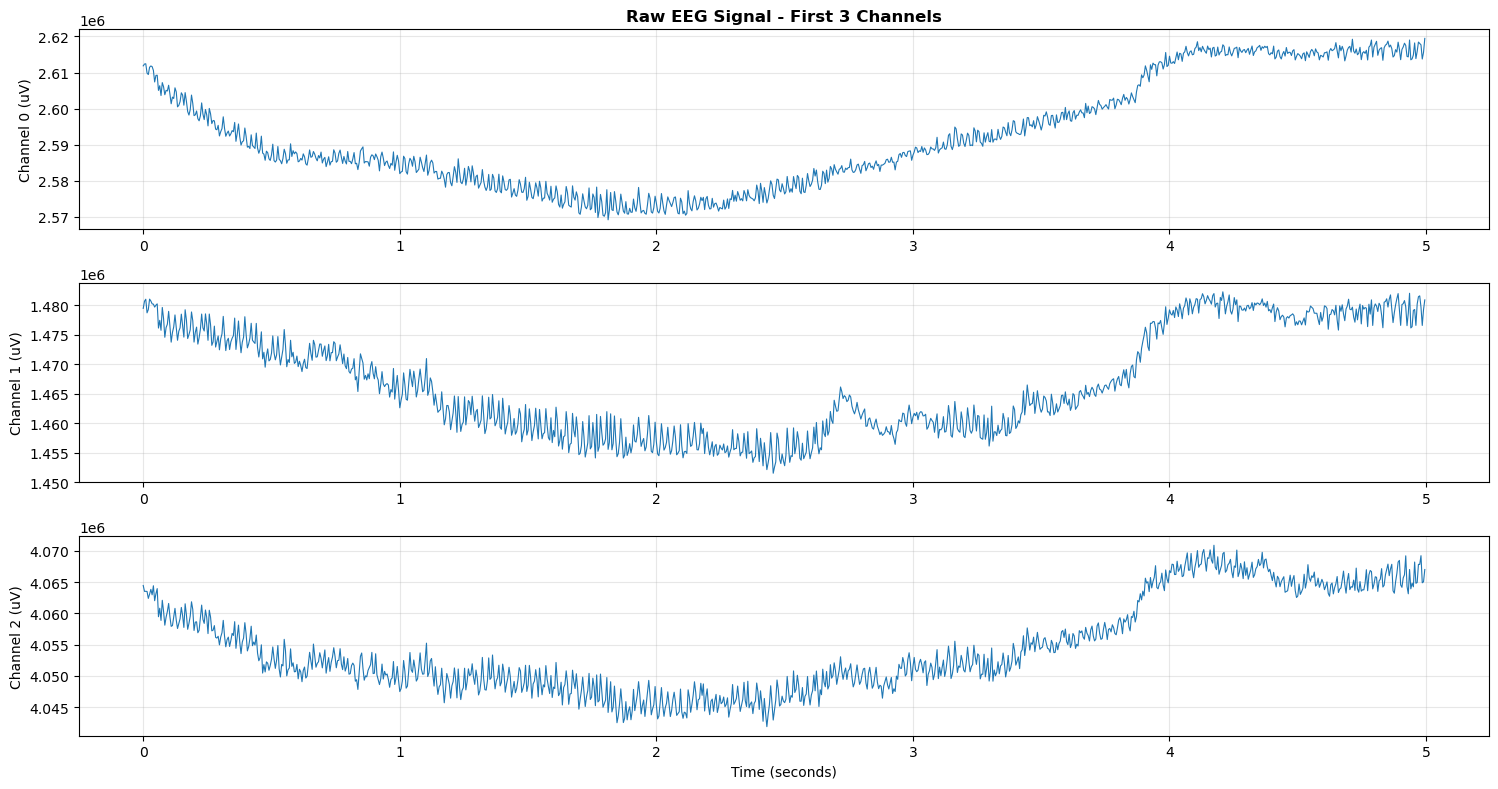


观察要点:
1. 原始EEG信号数值很大(通常在百万级),需要标准化处理
2. 信号中包含多种频率成分的混合
3. 可能存在基线漂移和高频噪声


In [ ]:
# ============================================================================
# 第二步：可视化原始EEG信号
# ============================================================================

# ----------------------------------------------------------------------------
# 定义采样率（每秒采集多少个数据点）
# ----------------------------------------------------------------------------
sampling_rate = 202  # Hz（赫兹），表示每秒采集202个数据点

# ----------------------------------------------------------------------------
# 计算时间轴（将样本索引转换为时间，单位：秒）
# ----------------------------------------------------------------------------
# 获取总样本数（时间点数）
n_samples = eeg_array.shape[0]

# 创建时间轴：[0, 1/202, 2/202, ..., n_samples/202]
# np.arange(n_samples)生成[0, 1, 2, ..., n_samples-1]
# 除以采样率后得到以秒为单位的时间点
time_axis = np.arange(n_samples) / sampling_rate

# ----------------------------------------------------------------------------
# 为了图形清晰，只显示前5秒的数据
# ----------------------------------------------------------------------------
duration = 5  # 显示的时长（秒）
n_points = duration * sampling_rate  # 前5秒对应的数据点数：5 × 202 = 1010个点

# ----------------------------------------------------------------------------
# 创建一个图形窗口，大小为15×8英寸
# ----------------------------------------------------------------------------
plt.figure(figsize=(15, 8))

# ----------------------------------------------------------------------------
# 绘制前3个通道的波形（共16个通道，这里只显示前3个）
# ----------------------------------------------------------------------------
for i in range(3):
    # 创建子图：3行1列，当前是第i+1个子图
    plt.subplot(3, 1, i+1)
    
    # 绘制该通道的时域波形
    # time_axis[:n_points]: 前5秒的时间轴
    # eeg_array[:n_points, i]: 第i个通道的前5秒数据
    # linewidth=0.8: 线条宽度
    plt.plot(time_axis[:n_points], eeg_array[:n_points, i], linewidth=0.8)
    
    # Y轴标签：显示通道编号和单位
    plt.ylabel(f'Channel {i} (uV)', fontsize=10)
    
    # 显示网格，alpha=0.3表示半透明
    plt.grid(True, alpha=0.3)
    
    # 只在第一个子图上显示总标题
    if i == 0:
        plt.title('Raw EEG Signal - First 3 Channels', fontsize=12, fontweight='bold')
    
    # 只在最后一个子图上显示X轴标签
    if i == 2:
        plt.xlabel('Time (seconds)', fontsize=10)

# 自动调整子图布局，避免重叠
plt.tight_layout()

# 显示图形
plt.show()

# ----------------------------------------------------------------------------
# 打印观察要点，帮助理解原始信号的特征
# ----------------------------------------------------------------------------
print("\n观察要点:")
print("1. 原始EEG信号数值很大(通常在百万级),需要标准化处理")
print("2. 信号中包含多种频率成分的混合")
print("3. 可能存在基线漂移和高频噪声")

波形图的深入解读


#### 波形图的基本信息

这个图表展示了**原始EEG信号的前3个通道**（Channel 0、Channel 1、Channel 2）的时域波形，时间窗口为前5秒的数据。

**技术参数：**
- **采样率**: 202 Hz（每秒采集202个数据点）
- **时间范围**: 0-5秒
- **数据点数**: 1010个点（5秒 × 202点/秒）
- **通道数**: 3个通道（实际数据有16个通道）

####  关键观察点

##### 1. **信号幅度异常大**

从波形图可以观察到，三个通道的信号幅度都非常大：

- **Channel 0**: 约 2.57-2.62 × 10⁶ μV（约257-262万微伏）
- **Channel 1**: 约 1.45-1.48 × 10⁶ μV（约145-148万微伏）
- **Channel 2**: 约 4.045-4.070 × 10⁶ μV（约404-407万微伏）

**为什么数值这么大？**
- 这是**原始未处理的信号**，包含了大量的直流分量和基线偏移
- 不同通道的绝对幅度差异很大，反映了不同电极位置的信号强度差异
- 这种巨大的数值范围不适合直接用于机器学习模型，必须进行标准化处理

##### 2. **三个通道的相似趋势模式**

仔细观察三个通道的波形，可以发现它们都遵循相似的变化模式：

- **0-2.2秒**: 信号逐渐下降，可能反映了：
  - 实验开始时的状态调整
  - 基线漂移的影响
  - 被试者注意力的变化
  
- **2.2-3.8秒**: 信号逐渐上升，可能反映了：
  - 认知任务的进行
  - 脑电活动的增强
  - 注意力的集中
  
- **3.8-4.0秒**: 出现明显的**阶跃式上升**，可能反映了：
  - 实验刺激的出现
  - 被试者状态的突然变化
  - 外部事件的影响
  
- **4.0-5.0秒**: 信号相对稳定，可能反映了：
  - 状态的稳定化
  - 持续的认知活动

**这种相似性说明了什么？**
- 三个通道可能记录到了**共同的事件或刺激**
- 可能存在**共同的伪迹**（如眼动、肌电、设备噪声）
- 存在**共同的基线漂移**，这是需要滤波去除的

##### 3. **高频噪声明显**

从波形图中可以清楚地看到，信号上叠加了大量的**高频振荡**，表现为细密的波动。这说明：

- 信号包含了**多种频率成分的混合**
- 存在**高频噪声**（如肌电干扰、工频干扰50/60Hz）
- 需要带通滤波器来去除不需要的频率成分

##### 4. **通道间幅度差异**

虽然三个通道的变化模式相似，但它们的**绝对幅度差异很大**：

- Channel 0: 约260万μV
- Channel 1: 约146万μV（最小）
- Channel 2: 约405万μV（最大）

**这种差异的原因：**
- 不同电极位置对同一事件的响应强度不同
- 电极与头皮的接触阻抗不同
- 不同脑区的信号强度自然不同

**为什么需要逐通道标准化？**
- 消除通道间的幅度差异，让模型关注信号的变化模式而非绝对数值
- 确保所有通道对模型的贡献是平等的

#### 实际意义

这个原始波形图告诉我们：

1. **为什么需要预处理**：
   - 原始信号数值太大，不适合直接输入模型
   - 存在基线漂移、高频噪声等干扰
   - 通道间差异需要标准化处理

2. **预处理的重要性**：
   - 带通滤波（0.5-40Hz）可以去除极低频漂移和高频噪声
   - Z-score标准化可以消除通道间差异
   - 这些步骤是后续深度学习模型成功的关键

3. **信号质量评估**：
   - 虽然存在噪声，但信号的基本趋势是清晰的
   - 三个通道的同步变化说明信号质量良好
   - 经过预处理后，这些信号可以用于情绪识别

####  与后续处理的关系

这个原始波形图是理解整个预处理流程的起点：

```
原始信号
    ↓
带通滤波（0.5-40Hz）→ 去除基线漂移和高频噪声
    ↓
Z-score标准化 → 消除通道间差异
    ↓
裁剪到[-20, 20] → 去除异常值
    ↓
滑动窗口切分 → 准备模型输入
```

通过对比原始信号和预处理后的信号，我们可以直观地看到每个步骤的效果，这也是为什么这个可视化图表如此重要的原因。

### 1.4 数组基本操作练习

让我们练习一些NumPy的基本操作,这些在后续的信号处理中会经常用到。



In [ ]:
# ============================================================================
# 第三步：NumPy数组基本操作练习
# ============================================================================

# ----------------------------------------------------------------------------
# 选择第一个通道的数据进行操作演示
# ----------------------------------------------------------------------------
# 使用切片操作 [:, 0] 表示：所有行，第0列
# 这样我们得到一个一维数组，包含第0个通道的所有时间点数据
channel_0 = eeg_array[:, 0]

print("=== NumPy Array Basic Operations ===")

# ----------------------------------------------------------------------------
# 操作1：计算基本统计量
# ----------------------------------------------------------------------------
# 统计量可以帮助我们了解数据的分布特征
print(f"\n1. Statistical Measures:")

# 均值（平均值）：所有数据点的总和除以数据点数量
print(f"   Mean: {np.mean(channel_0):.2f}")

# 标准差：衡量数据的离散程度，数值越大表示数据波动越大
print(f"   Standard Deviation: {np.std(channel_0):.2f}")

# 最小值：数据中的最小值
print(f"   Min: {np.min(channel_0):.2f}")

# 最大值：数据中的最大值
print(f"   Max: {np.max(channel_0):.2f}")

# ----------------------------------------------------------------------------
# 操作2：数组切片操作
# ----------------------------------------------------------------------------
# 切片是NumPy中最常用的操作之一，用于提取数组的一部分
print(f"\n2. Array Slicing:")

# 提取前1秒的数据
# [:sampling_rate] 表示从索引0到sampling_rate-1，共sampling_rate个点
# 因为采样率是202Hz，所以前1秒有202个数据点
first_second = channel_0[:sampling_rate]

print(f"   First 1 second has {len(first_second)} points")

# ----------------------------------------------------------------------------
# 操作3：Z-score标准化（重要！）
# ----------------------------------------------------------------------------
# Z-score标准化是EEG数据预处理的关键步骤
print(f"\n3. Standardization (Z-score):")

# 步骤1：计算均值
mean = np.mean(channel_0)

# 步骤2：计算标准差
std = np.std(channel_0)

# 步骤3：应用Z-score公式：z = (x - mean) / std
# 这个公式将数据转换为均值为0、标准差为1的标准正态分布
channel_0_normalized = (channel_0 - mean) / std

# 验证标准化结果
print(f"   After normalization:")

# 标准化后的均值应该接近0（理论上等于0，但因浮点数精度可能有微小误差）
print(f"   Mean: {np.mean(channel_0_normalized):.6f} (should be ~0)")

# 标准化后的标准差应该接近1
print(f"   Std: {np.std(channel_0_normalized):.6f} (should be ~1)")

=== NumPy Array Basic Operations ===

1. Statistical Measures:
   Mean: 2663330.02
   Standard Deviation: 79303.02
   Min: 2443570.00
   Max: 2764146.00

2. Array Slicing:
   First 1 second has 202 points

3. Standardization (Z-score):
   After normalization:
   Mean: 0.000000 (should be ~0)
   Std: 1.000000 (should be ~1)


**验证结果：**
- 标准化后的均值应该接近 **0**
- 标准化后的标准差应该接近 **1**

#####  实际效果

输出可以看到：
- **原始数据**：
  - 均值：2,663,330.02（约266万）
  - 标准差：79,303.02（约7.9万）
  - 范围：2,443,570 到 2,764,146

- **标准化后**：
  - 均值：0.000000
  - 标准差：1.000000
  - 范围：约-2.8到+1.3（相对于标准差）

#### 1.4.1 Z-score标准化详解

学习**Z-score标准化**（也称为零均值标准化），这是EEG信号预处理中的关键步骤。

#####  什么是Z-score标准化？

Z-score标准化是一种数据归一化方法，将数据转换为**均值为0、标准差为1**的标准正态分布形式。

**数学公式：**
```
z = (x - μ) / σ
```
其中：
- `x`: 原始数据值
- `μ`: 数据的均值（mean）
- `σ`: 数据的标准差（standard deviation）
- `z`: 标准化后的值

##### 为什么需要标准化？

1. **消除数值尺度差异**
   - 原始EEG信号数值非常大（百万级），不同通道的幅度差异也很大
   - 标准化后，所有数据都在相似的尺度范围内（例如-3到+3之间）

2. **消除通道间差异**
   - 不同电极位置的信号强度不同（如Channel 0约260万μV，Channel 1约146万μV）
   - 标准化后，所有通道的均值为0、标准差为1，消除了绝对幅度的差异
   - 模型可以专注于**信号的变化模式**，而不是绝对数值

3. **提高模型训练效率**
   - 深度学习模型对输入数据的尺度很敏感
   - 标准化后的数据可以：
     - 加快梯度下降的收敛速度
     - 避免某些通道因为数值大而主导模型
     - 提高数值稳定性

4. **符合统计假设**
   - 许多机器学习算法假设数据是标准化的
   - 标准化后的数据更符合正态分布假设

#####  标准化的步骤

在代码中，标准化的实现非常简单：

```python
# 1. 计算均值和标准差
mean = np.mean(channel_0)      # 计算均值
std = np.std(channel_0)        # 计算标准差

# 2. 应用Z-score公式
channel_0_normalized = (channel_0 - mean) / std
```


#####  重要注意事项

1. **逐通道标准化**
   - 在EEG处理中，通常对**每个通道单独进行标准化**
   - 因为不同通道的幅度差异很大，需要分别处理
   - 项目中的预处理流程就是逐通道标准化的

2. **保持信号形状**
   - 标准化**不会改变信号的形状和相对变化**
   - 只是将信号"平移"和"缩放"到标准尺度
   - 信号的时间序列特征完全保留

3. **与滤波的关系**
   - 在实际项目中，标准化通常在**滤波之后**进行
   - 先滤波去除噪声，再标准化消除尺度差异
   - 这样可以确保标准化的是"干净"的信号

现在让我们运行下面的代码，看看标准化的实际效果！

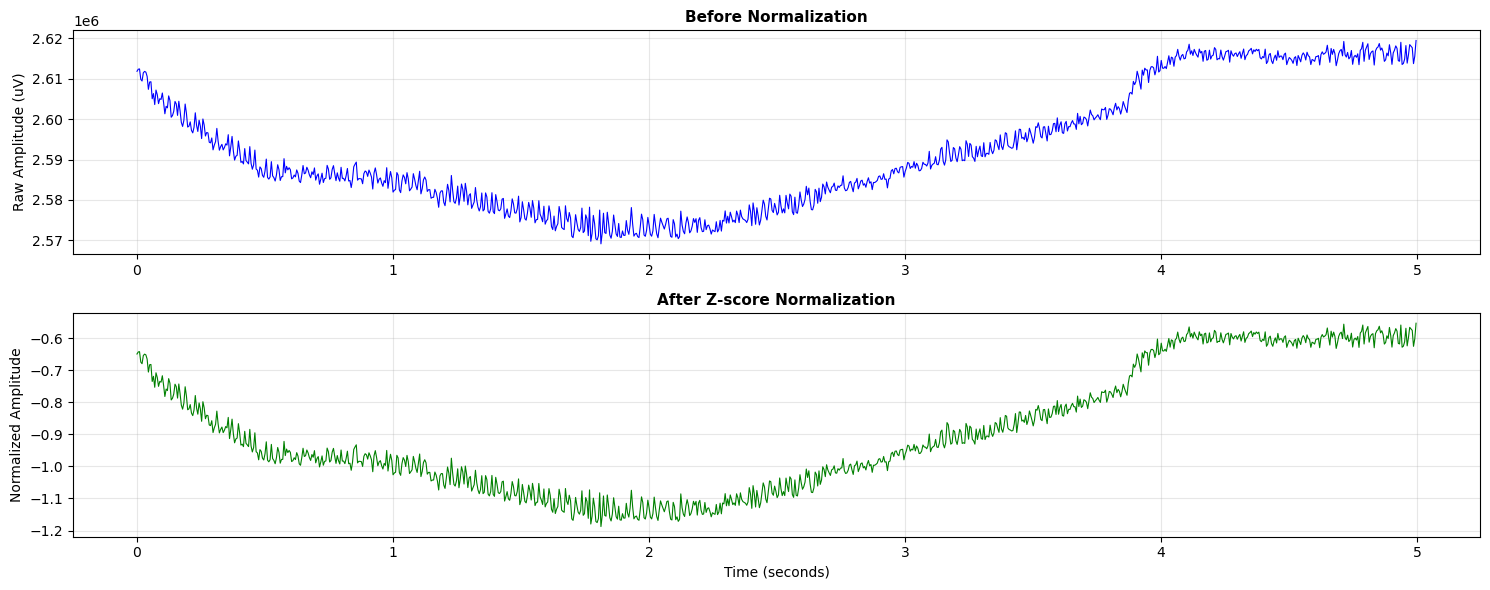

In [ ]:
# ============================================================================
# 可视化对比：标准化前后的信号变化
# ============================================================================

# ----------------------------------------------------------------------------
# 创建包含2个子图的图形窗口（上下排列）
# ----------------------------------------------------------------------------
# subplots(2, 1)：创建2行1列的子图布局
# figsize=(15, 6)：图形窗口大小为15×6英寸
fig, axes = plt.subplots(2, 1, figsize=(15, 6))

# ----------------------------------------------------------------------------
# 上图：显示标准化前的原始信号
# ----------------------------------------------------------------------------
# axes[0]表示第一个子图（上图）
axes[0].plot(
    time_axis[:n_points],        # X轴：时间（前5秒）
    channel_0[:n_points],        # Y轴：原始信号幅度
    linewidth=0.8,               # 线条宽度
    color='blue'                 # 线条颜色：蓝色
)
axes[0].set_ylabel('Raw Amplitude (uV)', fontsize=10)  # Y轴标签
axes[0].set_title('Before Normalization', fontsize=11, fontweight='bold')  # 子图标题
axes[0].grid(True, alpha=0.3)  # 显示网格，alpha=0.3表示半透明

# ----------------------------------------------------------------------------
# 下图：显示标准化后的信号
# ----------------------------------------------------------------------------
# axes[1]表示第二个子图（下图）
axes[1].plot(
    time_axis[:n_points],              # X轴：时间（前5秒）
    channel_0_normalized[:n_points],   # Y轴：标准化后的幅度
    linewidth=0.8,                     # 线条宽度
    color='green'                      # 线条颜色：绿色
)
axes[1].set_ylabel('Normalized Amplitude', fontsize=10)  # Y轴标签（无单位，已标准化）
axes[1].set_xlabel('Time (seconds)', fontsize=10)        # X轴标签
axes[1].set_title('After Z-score Normalization', fontsize=11, fontweight='bold')  # 子图标题
axes[1].grid(True, alpha=0.3)  # 显示网格

# ----------------------------------------------------------------------------
# 调整布局并显示图形
# ----------------------------------------------------------------------------
# tight_layout()自动调整子图参数，使之填充整个图形区域，避免重叠
plt.tight_layout()

# 显示图形窗口
plt.show()

#### 1.4.2 标准化前后可视化对比解读

展示了标准化前后的波形对比图，让我们详细解读这两个图表的差异和意义。

#####  图表结构

对比图包含两个子图，上下排列：
- **上图（蓝色）**: 标准化前的原始信号
- **下图（绿色）**: 标准化后的信号

#####  上图分析：标准化前（Before Normalization）

**Y轴特征：**
- **标签**: "Raw Amplitude (uV)"
- **数值范围**: 约 2.57 × 10⁶ 到 2.62 × 10⁶ μV（257-262万微伏）
- **Y轴刻度**: 显示为 `1e6` 的倍数，说明数值确实非常大

**波形特征：**
- **起始位置**: 约 2.61 × 10⁶ μV（t=0秒）
- **下降阶段**: 从0秒到约2.5秒，信号逐渐下降
  - 最低点：约 2.575 × 10⁶ μV（约2.5秒处）
  - 下降幅度：约 35,000 μV（约3.5万微伏）
- **上升阶段**: 从2.5秒到5秒，信号逐渐上升
  - 最终值：约 2.61 × 10⁶ μV（回到起始水平）
- **高频振荡**: 信号上叠加了明显的高频波动（噪声）

**关键观察：**
1. 数值巨大，不适合直接用于机器学习
2. 信号变化相对较小（相对于总幅度）
3. 存在明显的基线漂移（整体下降后上升的趋势）

#####  下图分析：标准化后（After Z-score Normalization）

**Y轴特征：**
- **标签**: "Normalized Amplitude"（无量纲）
- **数值范围**: 约 -1.2 到 -0.6
- **Y轴刻度**: 标准化的数值，没有单位

**波形特征：**
- **起始位置**: 约 -0.7（t=0秒）
- **下降阶段**: 从0秒到约2.5秒，信号逐渐下降
  - 最低点：约 -1.15（约2.5秒处）
  - 下降幅度：约 0.45（标准化单位）
- **上升阶段**: 从2.5秒到5秒，信号逐渐上升
  - 最终值：约 -0.7（回到起始水平）
- **高频振荡**: 保留了相同的高频波动模式

**关键观察：**
1. 数值范围合理（-1.2到-0.6），适合机器学习
2. 信号形状**完全保留**（与上图一致）
3. 相对变化更加明显（相对于总幅度）

#####  对比分析

| 特征 | 标准化前 | 标准化后 |
|------|---------|---------|
| **数值范围** | 2.57-2.62 × 10⁶ μV | -1.2 到 -0.6 |
| **均值** | 约 2.66 × 10⁶ μV | 0 |
| **标准差** | 约 79,303 μV | 1 |
| **信号形状** | 下降→上升 | 完全相同 |
| **相对变化** | 约1.3% | 约50% |
| **适合模型** | 不适合 | 适合 |

#####  关键发现

1. **形状完全保留**
   - 两个图的波形形状**一模一样**
   - 标准化只是"平移"和"缩放"，不改变信号的相对关系
   - 这说明标准化是**可逆的**（理论上可以还原）

2. **相对变化更明显**
   - 标准化前：变化约35,000 μV，相对于260万μV只有1.3%
   - 标准化后：变化约0.45，相对于总范围约50%
   - **标准化放大了信号的相对变化**，使模型更容易学习

3. **数值尺度合理**
   - 标准化后的数值在-3到+3之间（标准正态分布范围）
   - 这个范围对深度学习模型来说是最优的
   - 避免了数值溢出和梯度消失问题

4. **为什么是负值？**
   - 标准化后的均值是0
   - 如果原始信号大部分值低于均值，标准化后就会是负值
   - 这是正常的，因为标准化是相对于均值的偏移

#####  实际意义

这个对比图清楚地展示了：

1. **标准化的必要性**
   - 原始信号数值太大，不适合直接输入模型
   - 标准化后数值范围合理，模型训练更稳定

2. **标准化的有效性**
   - 信号形状完全保留，没有信息损失
   - 相对变化更加明显，有利于特征提取

3. **预处理的重要性**
   - 这是整个预处理流程中的关键一步
   - 与滤波、裁剪等步骤配合，为模型提供高质量输入

##### 在项目中的应用

在项目的完整预处理流程中，标准化是第三步：

```
1. 读取CSV文件
2. 带通滤波（0.5-40Hz）→ 去除噪声
3. Z-score标准化（逐通道）→ 消除尺度差异 ← 我们在这里！
4. 裁剪到[-20, 20] → 去除异常值
5. 滑动窗口切分 → 准备模型输入
```

**逐通道标准化**确保了：
- 每个通道的均值为0、标准差为1
- 所有通道对模型的贡献是平等的
- 模型可以学习通道间的相对关系，而不是绝对数值

通过这个可视化对比，我们可以直观地理解标准化的效果和重要性！

---

## 第二部分：EEG信号处理入门
## Part 2: Introduction to EEG Signal Processing

### 2.1 为什么需要信号处理？

原始EEG信号包含多种成分：
- **有用信号**: 大脑神经活动产生的电信号(4-40Hz)
- **噪声**: 
  - 基线漂移(0-4Hz)
  - 工频干扰(50Hz或60Hz)
  - 高频肌电噪声(>40Hz)

信号处理的目标就是**保留有用信号,去除噪声**。

### 2.2 带通滤波器 (Bandpass Filter)

带通滤波器允许特定频率范围的信号通过,滤除其他频率。

**在本项目中,我们使用0.5-40Hz的带通滤波器**（与main.py中的预处理流程完全一致）：
- **低于0.5Hz**: 极低频漂移和直流分量
- **0.5-40Hz**: 有用的脑电信号
  - δ波(0.5-4Hz): 深度睡眠
  - θ波(4-8Hz): 困倦、冥想
  - α波(8-13Hz): 放松、闭眼
  - β波(13-30Hz): 警觉、专注
  - γ波(30-40Hz): 高度认知活动
- **高于40Hz**: 肌电噪声


In [ ]:
# ============================================================================
# 定义带通滤波器函数（Bandpass Filter）
# ============================================================================

def bandpass_filter(data, sampling_rate, lowcut, highcut):
    """
    巴特沃斯带通滤波器（Butterworth Bandpass Filter）
    
    这个函数与项目中main.py的预处理流程完全一致！
    
    参数说明:
        data: 输入信号数组，形状可以是(时间点数,)或(时间点数, 通道数)
        sampling_rate: 采样率(Hz)，本项目中为202Hz
        lowcut: 低频截止频率(Hz)，低于此频率的信号将被滤除
        highcut: 高频截止频率(Hz)，高于此频率的信号将被滤除
    
    返回:
        filtered_data: 滤波后的信号，形状与输入相同
    
    工作原理:
        带通滤波器允许特定频率范围(lowcut到highcut)的信号通过，
        同时抑制低于lowcut和高于highcut的频率成分。
    """
    # ------------------------------------------------------------------------
    # 步骤1：计算奈奎斯特频率（Nyquist Frequency）
    # ------------------------------------------------------------------------
    # 奈奎斯特频率 = 采样率的一半
    # 根据采样定理，只能准确重建低于奈奎斯特频率的信号
    # 对于202Hz的采样率，奈奎斯特频率为101Hz
    nyquist = 0.5 * sampling_rate
    
    # ------------------------------------------------------------------------
    # 步骤2：归一化截止频率
    # ------------------------------------------------------------------------
    # SciPy的butter函数要求截止频率归一化到[0, 1]范围
    # 其中1对应奈奎斯特频率
    low = lowcut / nyquist    # 低频截止频率归一化
    high = highcut / nyquist  # 高频截止频率归一化
    
    # ------------------------------------------------------------------------
    # 步骤3：设计4阶巴特沃斯带通滤波器
    # ------------------------------------------------------------------------
    # signal.butter()设计滤波器，返回滤波器系数b和a
    # 参数说明：
    #   - 4: 滤波器阶数，阶数越高，过渡带越陡峭，但计算复杂度也越高
    #   - [low, high]: 归一化后的截止频率范围
    #   - btype='band': 带通滤波器类型
    # 返回值：
    #   - b: 分子系数（numerator coefficients）
    #   - a: 分母系数（denominator coefficients）
    b, a = signal.butter(4, [low, high], btype='band')
    
    # ------------------------------------------------------------------------
    # 步骤4：应用滤波器进行零相位滤波
    # ------------------------------------------------------------------------
    # signal.filtfilt()执行前向-后向滤波，优点：
    #   1. 零相位延迟：不会改变信号的时间位置
    #   2. 更好的幅频响应：等效于平方幅频响应
    # 参数说明：
    #   - b, a: 滤波器系数
    #   - data: 输入信号
    #   - axis=0: 沿着第0维（时间维度）进行滤波
    filtered_data = signal.filtfilt(b, a, data, axis=0)
    
    return filtered_data

# ============================================================================
# 应用带通滤波器到EEG数据
# ============================================================================

# 使用项目中的标准参数：0.5-40Hz
# - lowcut=0.5Hz: 去除极低频漂移（<0.5Hz）
# - highcut=40Hz: 去除高频肌电噪声（>40Hz）
# - 保留0.5-40Hz的脑电信号（包含δ、θ、α、β、γ波）
eeg_filtered = bandpass_filter(
    eeg_array,           # 输入：原始EEG数据
    sampling_rate,       # 采样率：202Hz
    lowcut=0.5,          # 低频截止：0.5Hz
    highcut=40           # 高频截止：40Hz
)

# 打印滤波结果信息
print("Bandpass filter (0.5-40Hz) applied successfully!")
print(f"Filtered data shape: {eeg_filtered.shape}")
print("This is the SAME preprocessing used in the deep learning model!")

Bandpass filter (0.5-40Hz) applied successfully!
Filtered data shape: (65852, 16)
This is the SAME preprocessing used in the deep learning model!


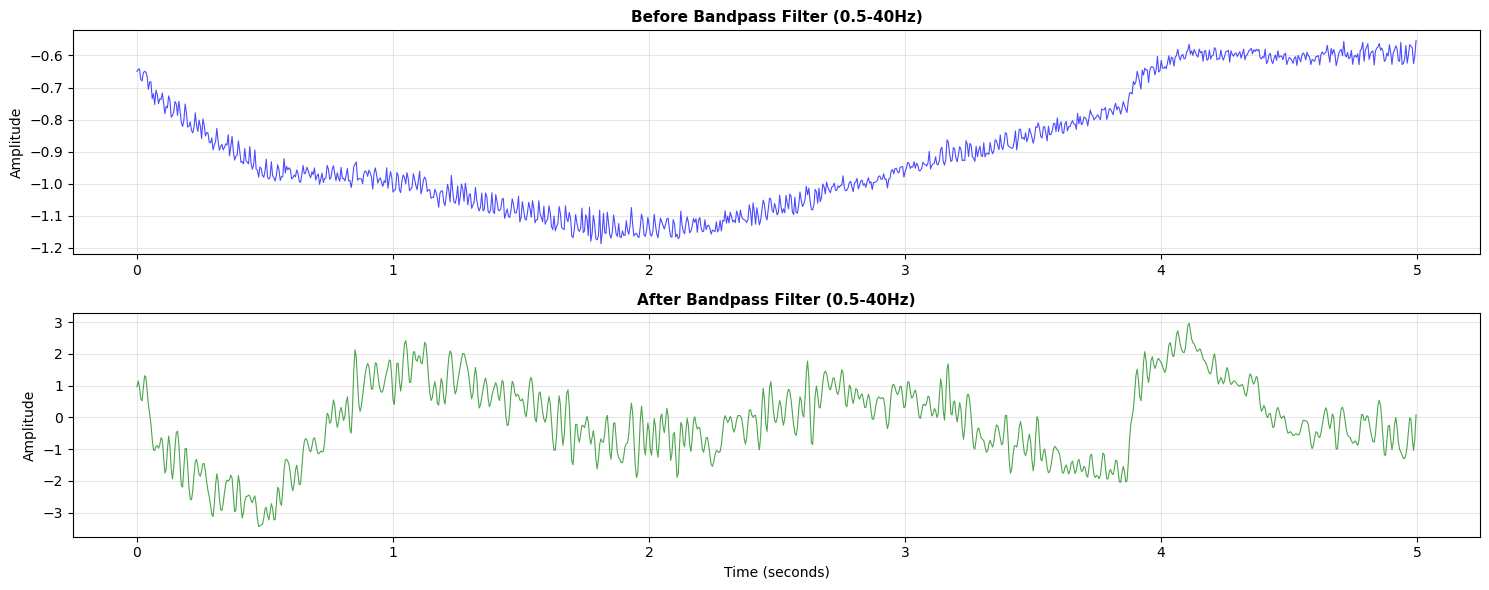


观察要点:
1. 滤波后的信号更加'干净',去除了极低频漂移(<0.5Hz)
2. 高频肌电噪声(>40Hz)也被抑制了
3. 保留了0.5-40Hz范围内的脑电活动特征
4. 这就是深度学习模型训练时使用的预处理方法!


In [ ]:
# ============================================================================
# 可视化带通滤波的效果
# ============================================================================

# ----------------------------------------------------------------------------
# 选择要可视化的通道
# ----------------------------------------------------------------------------
channel_idx = 0  # 选择第一个通道（Channel 0）进行对比

# ----------------------------------------------------------------------------
# 为了公平对比，需要对原始信号和滤波后的信号都进行标准化
# ----------------------------------------------------------------------------
# 原始信号的Z-score标准化
# 计算公式：(x - mean) / std
raw_normalized = (eeg_array[:, channel_idx] - np.mean(eeg_array[:, channel_idx])) / np.std(eeg_array[:, channel_idx])

# 滤波后信号的Z-score标准化
filtered_normalized = (eeg_filtered[:, channel_idx] - np.mean(eeg_filtered[:, channel_idx])) / np.std(eeg_filtered[:, channel_idx])

# ----------------------------------------------------------------------------
# 创建2行1列的子图布局
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(15, 6))

# ----------------------------------------------------------------------------
# 上图：滤波前的原始信号（已标准化）
# ----------------------------------------------------------------------------
axes[0].plot(
    time_axis[:n_points],           # X轴：时间（前5秒）
    raw_normalized[:n_points],      # Y轴：标准化后的原始信号
    linewidth=0.8,                  # 线条宽度
    color='blue',                   # 蓝色
    alpha=0.7                       # 透明度70%
)
axes[0].set_ylabel('Amplitude', fontsize=10)  # Y轴标签
axes[0].set_title('Before Bandpass Filter (0.5-40Hz)', fontsize=11, fontweight='bold')  # 标题
axes[0].grid(True, alpha=0.3)  # 显示网格

# ----------------------------------------------------------------------------
# 下图：带通滤波后的信号（已标准化）
# ----------------------------------------------------------------------------
axes[1].plot(
    time_axis[:n_points],               # X轴：时间（前5秒）
    filtered_normalized[:n_points],     # Y轴：标准化后的滤波信号
    linewidth=0.8,                      # 线条宽度
    color='green',                      # 绿色
    alpha=0.7                           # 透明度70%
)
axes[1].set_ylabel('Amplitude', fontsize=10)         # Y轴标签
axes[1].set_xlabel('Time (seconds)', fontsize=10)    # X轴标签
axes[1].set_title('After Bandpass Filter (0.5-40Hz)', fontsize=11, fontweight='bold')  # 标题
axes[1].grid(True, alpha=0.3)  # 显示网格

# 调整布局并显示
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 打印观察要点
# ----------------------------------------------------------------------------
print("\n观察要点:")
print("1. 滤波后的信号更加'干净',去除了极低频漂移(<0.5Hz)")
print("2. 高频肌电噪声(>40Hz)也被抑制了")
print("3. 保留了0.5-40Hz范围内的脑电活动特征")
print("4. 这就是深度学习模型训练时使用的预处理方法!")

#### 2.2.1 带通滤波前后时域波形对比解读

我们用同一个通道（Channel 0）的信号，比较了**带通滤波前后**的时域波形。这里对这两个图做一个详细的分析与解读。

##### 图表结构

- **上图（蓝色）**：`Before Bandpass Filter (0.5-40Hz)`  —— 仅做了Z-score标准化的原始信号
- **下图（绿色）**：`After Bandpass Filter (0.5-40Hz)` —— 在0.5–40Hz带通滤波后，再标准化的信号

两个图的横轴都是**时间（0–5秒）**，这样可以一一对比同一时间点上，滤波前后信号的变化。

##### 上图：滤波前（Before Bandpass Filter）

**信号特点：**
- 整体是一个**缓慢下降再上升**的趋势：
  - 0–2.5秒：幅度缓慢下降
  - 2.5–5秒：幅度缓慢上升
- 叠加有一定的高频振荡，但整体看上去比较“平滑”，更像是一个**大尺度的弯曲曲线**。

**这说明了什么？**
- 这种缓慢变化对应的是**极低频成分（<0.5Hz）**，可以理解为：
  - 基线漂移（baseline drift）
  - 电极接触变化
  - 头皮/身体缓慢移动
- 对于情绪识别这类任务，这种极低频漂移一般**不是有用的脑电活动**，反而会干扰模型学习。

##### 下图：滤波后（After Bandpass Filter）

**信号特点：**
- 原来的“大弯曲趋势”基本消失，整体围绕0上下波动。
- 可以清楚看到更多**中等频率的振荡**结构，波形看起来更“起伏不定”，细节更丰富。
- 某些时间段（比如3.5–4.5秒），振幅明显增大，说明这一时段内脑电活动更强。

**这说明了什么？**
- 带通滤波已经**去掉了极低频漂移**（<0.5Hz），所以不再看到缓慢的大弯曲趋势。
- 同时也**抑制了高于40Hz的高频噪声**（如肌电），保留的是0.5–40Hz范围内的脑电成分：
  - δ（0.5–4Hz）、θ（4–8Hz）、α（8–13Hz）、β（13–30Hz）、γ（30–40Hz）
- 滤波后信号更加“紧凑”，更像我们在教科书中看到的EEG波形。

##### 前后对比要点

1. **基线趋势**：
   - 滤波前：有明显的整体上升/下降趋势，是低频漂移。
   - 滤波后：基线围绕0上下小范围波动，漂移被去除。

2. **有用信息的突出**：
   - 滤波前：低频大趋势占主导，掩盖了中高频的脑电节律。
   - 滤波后：α、β等频段的节律更清晰，有利于观察和特征提取。

3. **噪声抑制**：
   - 高频肌电噪声（>40Hz）被显著削弱，使波形更“顺滑”，但仍保留脑电本身的细节。

4. **与标准化的关系**：
   - 图中两条曲线都已经做了Z-score标准化，因此数值范围可比。
   - 差异主要来自**频率内容的变化**，而不是数值缩放。

#####  对情绪识别的意义

- 深度学习模型主要依赖**0.5–40Hz范围内的脑电活动模式**来区分 Alert / Relaxed / Nervous 等情绪状态。
- 如果不做带通滤波，模型会被：
  - 基线漂移
  - 工频干扰
  - 肌电噪声
 这些无关因素干扰，降低分类效果。
- 带通滤波后的信号：
  - 既去除了无关成分
  - 又保留了情绪相关的脑电节律
  - 是后续标准化、滑动窗口、特征提取和模型训练的**理想输入**。

通过这幅前后对比图，你可以直观地看到：
- 带通滤波不是“随便滤一滤”，而是**有目的地保留大脑有用频段**，
- 为后续的频谱分析和深度学习模型打下了一个“干净、可靠”的信号基础。

### 2.3 频谱分析 - FFT (快速傅里叶变换)

时域信号很难直观看出包含哪些频率成分,通过FFT可以将信号从时域转换到频域。

**频域图可以告诉我们:**
- 信号在哪些频率上能量最强
- 滤波器是否有效去除了不需要的频率成分
- α波、β波等不同频段的相对强度

In [ ]:
# ============================================================================
# 定义功率谱计算函数
# ============================================================================

def compute_power_spectrum(data, sampling_rate):
    """
    计算信号的功率谱密度（Power Spectral Density, PSD）
    
    功率谱密度描述了信号的能量在不同频率上的分布情况。
    通过功率谱，我们可以直观地看到信号在哪些频率上能量最强。
    
    参数:
        data: 输入信号（一维数组）
        sampling_rate: 采样率(Hz)，本项目为202Hz
    
    返回:
        freqs: 频率轴（Hz），例如[0, 0.2, 0.4, ..., 100]
        power: 功率谱密度，对应每个频率点的能量强度
    """
    # ------------------------------------------------------------------------
    # 使用Welch方法计算功率谱密度
    # ------------------------------------------------------------------------
    # Welch方法的优点：
    #   1. 将信号分成多个重叠的段
    #   2. 对每一段计算FFT（快速傅里叶变换）
    #   3. 对所有段的结果取平均
    #   4. 这样可以减少噪声的影响，得到更平滑、可靠的频谱
    # 
    # 参数说明：
    #   - data: 输入信号
    #   - fs: 采样率
    #   - nperseg: 每段的长度（样本数），1024是一个常用值
    #              更大的nperseg可以提高频率分辨率，但会增加方差
    freqs, power = signal.welch(data, fs=sampling_rate, nperseg=1024)
    
    return freqs, power

# ============================================================================
# 计算滤波前后的功率谱，用于对比分析
# ============================================================================

# ----------------------------------------------------------------------------
# 1. 计算原始信号的功率谱
# ----------------------------------------------------------------------------
# 首先对原始信号进行Z-score标准化
raw_signal = (eeg_array[:, channel_idx] - np.mean(eeg_array[:, channel_idx])) / np.std(eeg_array[:, channel_idx])

# 计算功率谱
freqs_raw, power_raw = compute_power_spectrum(raw_signal, sampling_rate)

# ----------------------------------------------------------------------------
# 2. 计算滤波后信号的功率谱
# ----------------------------------------------------------------------------
# 对滤波后的信号进行Z-score标准化
filtered_signal = (eeg_filtered[:, channel_idx] - np.mean(eeg_filtered[:, channel_idx])) / np.std(eeg_filtered[:, channel_idx])

# 计算功率谱
freqs_filtered, power_filtered = compute_power_spectrum(filtered_signal, sampling_rate)

print("Power spectrum calculated successfully!")

Power spectrum calculated successfully!


### 2.4 可视化频谱对比

让我们通过频谱图直观地看到滤波器的效果。

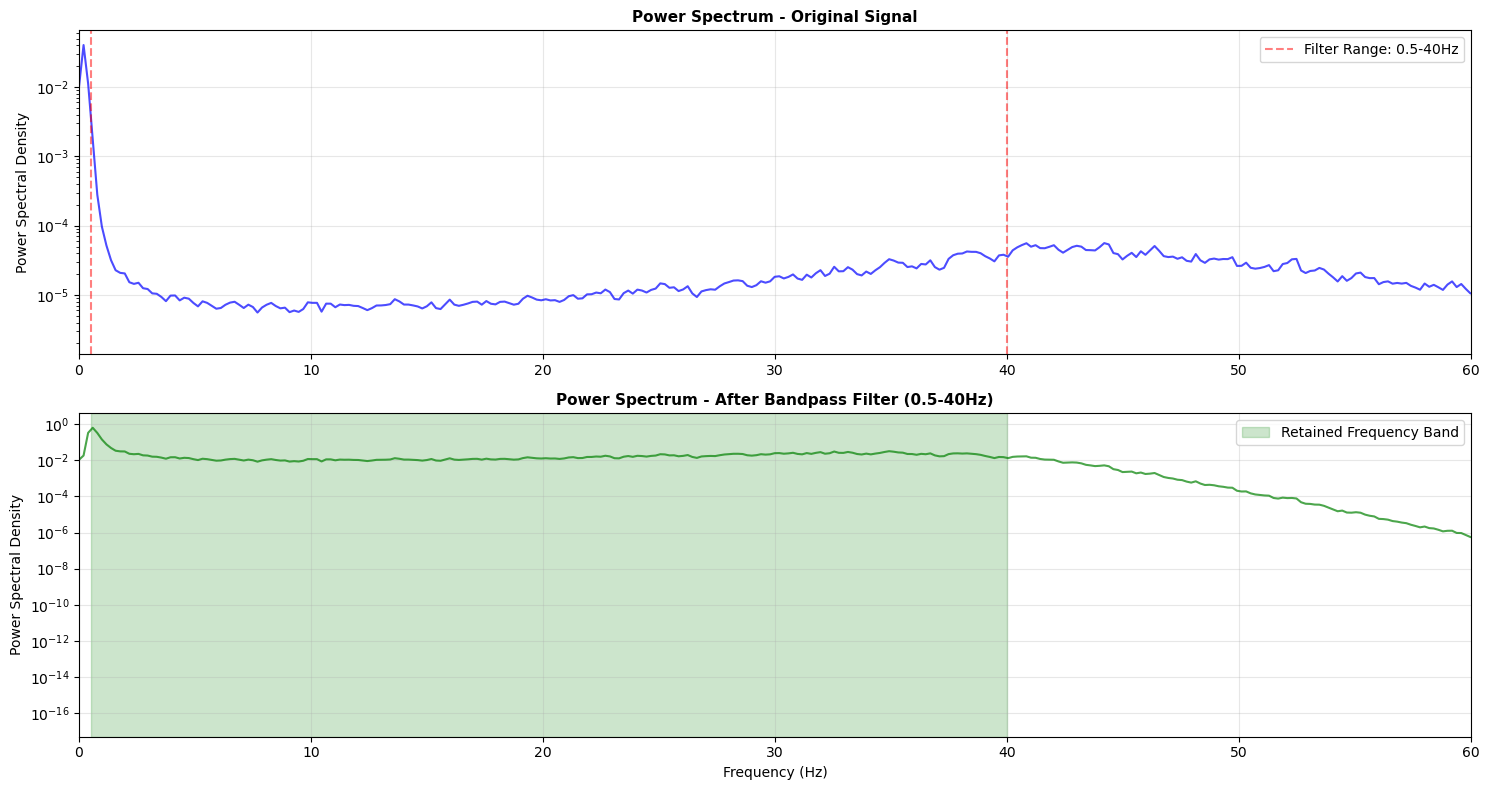


频谱分析要点:
1. 原始信号在极低频(<0.5Hz)有很大的能量(基线漂移)
2. 带通滤波后,只保留了0.5-40Hz范围的信号
3. 0.5Hz以下和40Hz以上的频率成分被有效抑制
4. 这确保了后续模型只学习有用的脑电特征


In [ ]:
# ============================================================================
# 可视化滤波前后的频谱对比
# ============================================================================

# ----------------------------------------------------------------------------
# 创建2行1列的子图布局
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# ----------------------------------------------------------------------------
# 设置频率显示范围
# ----------------------------------------------------------------------------
# 只显示0-60Hz的频率范围，因为：
#   1. EEG信号的主要成分在0-40Hz
#   2. 超过60Hz的部分对我们的分析意义不大
freq_limit = 60

# ----------------------------------------------------------------------------
# 上图：原始信号的功率谱
# ----------------------------------------------------------------------------
# 使用semilogy绘制：Y轴采用对数坐标，这样可以更清楚地看到不同数量级的功率
axes[0].semilogy(
    freqs_raw,           # X轴：频率（Hz）
    power_raw,           # Y轴：功率谱密度（对数坐标）
    linewidth=1.5,       # 线条宽度
    color='blue',        # 蓝色
    alpha=0.7            # 透明度70%
)
axes[0].set_xlim([0, freq_limit])  # 限制X轴显示范围：0-60Hz
axes[0].set_ylabel('Power Spectral Density', fontsize=10)  # Y轴标签
axes[0].set_title('Power Spectrum - Original Signal', fontsize=11, fontweight='bold')  # 标题
axes[0].grid(True, alpha=0.3)  # 显示网格

# 在图上标注滤波器的频率范围（0.5-40Hz）
# axvline: 画垂直线
axes[0].axvline(
    x=0.5,                                      # 在0.5Hz位置
    color='red',                                # 红色
    linestyle='--',                             # 虚线
    alpha=0.5,                                  # 半透明
    label='Filter Range: 0.5-40Hz'             # 图例标签
)
axes[0].axvline(x=40, color='red', linestyle='--', alpha=0.5)  # 在40Hz位置画第二条垂直线
axes[0].legend()  # 显示图例

# ----------------------------------------------------------------------------
# 下图：带通滤波后的功率谱
# ----------------------------------------------------------------------------
axes[1].semilogy(
    freqs_filtered,      # X轴：频率（Hz）
    power_filtered,      # Y轴：功率谱密度（对数坐标）
    linewidth=1.5,       # 线条宽度
    color='green',       # 绿色
    alpha=0.7            # 透明度70%
)
axes[1].set_xlim([0, freq_limit])  # 限制X轴显示范围：0-60Hz
axes[1].set_xlabel('Frequency (Hz)', fontsize=10)  # X轴标签
axes[1].set_ylabel('Power Spectral Density', fontsize=10)  # Y轴标签
axes[1].set_title('Power Spectrum - After Bandpass Filter (0.5-40Hz)', fontsize=11, fontweight='bold')  # 标题
axes[1].grid(True, alpha=0.3)  # 显示网格

# 用绿色阴影标注保留的频段（0.5-40Hz）
# axvspan: 画垂直跨度（阴影区域）
axes[1].axvspan(
    0.5, 40,                                    # 从0.5Hz到40Hz
    alpha=0.2,                                  # 透明度20%
    color='green',                              # 绿色
    label='Retained Frequency Band'             # 图例标签
)
axes[1].legend()  # 显示图例

# 调整布局并显示
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 打印频谱分析要点
# ----------------------------------------------------------------------------
print("\n频谱分析要点:")
print("1. 原始信号在极低频(<0.5Hz)有很大的能量(基线漂移)")
print("2. 带通滤波后,只保留了0.5-40Hz范围的信号")
print("3. 0.5Hz以下和40Hz以上的频率成分被有效抑制")
print("4. 这确保了后续模型只学习有用的脑电特征")

### 2.5 脑电频段分析

现在让我们分析不同频段的能量分布,这对情绪识别非常重要。

**常见脑电频段:**
- **δ波 (0.5-4Hz)**: 深度睡眠
- **θ波 (4-8Hz)**: 困倦、创造性思维
- **α波 (8-13Hz)**: 放松、闭眼静息
- **β波 (13-30Hz)**: 警觉、专注、思考
- **γ波 (30-40Hz)**: 高度认知活动

In [ ]:
# ============================================================================
# 定义计算频段能量的函数
# ============================================================================

def calculate_band_power(data, sampling_rate, band_range):
    """
    计算特定频段的平均能量
    
    这个函数用于提取EEG信号在特定频段（如α波、β波）的能量。
    不同频段的能量分布可以反映不同的脑电活动状态和情绪状态。
    
    参数:
        data: 输入信号（一维数组）
        sampling_rate: 采样率(Hz)
        band_range: 频段范围，例如(8, 13)表示8-13Hz的α波
    
    返回:
        band_power: 该频段的平均能量（标量值）
    """
    # ------------------------------------------------------------------------
    # 步骤1：计算信号的功率谱
    # ------------------------------------------------------------------------
    freqs, power = signal.welch(data, fs=sampling_rate, nperseg=1024)
    
    # ------------------------------------------------------------------------
    # 步骤2：找到指定频段的索引
    # ------------------------------------------------------------------------
    # np.logical_and创建一个布尔数组，标记哪些频率点在指定范围内
    # 例如：band_range=(8, 13)，则idx_band会标记8Hz到13Hz之间的所有频率点
    idx_band = np.logical_and(freqs >= band_range[0], freqs <= band_range[1])
    
    # ------------------------------------------------------------------------
    # 步骤3：计算该频段内的平均功率
    # ------------------------------------------------------------------------
    # power[idx_band]提取该频段内所有频率点的功率值
    # np.mean()计算这些功率值的平均值，作为该频段的总体能量
    band_power = np.mean(power[idx_band])
    
    return band_power

# ============================================================================
# 定义脑电频段
# ============================================================================

# 以下是标准的EEG频段划分：
# - Delta (δ): 0.5-4Hz - 深度睡眠、无意识状态
# - Theta (θ): 4-8Hz - 困倦、冥想、创造性思维
# - Alpha (α): 8-13Hz - 放松、闭眼静息
# - Beta (β): 13-30Hz - 警觉、专注、思考
# - Gamma (γ): 30-40Hz - 高度认知活动
bands = {
    'Delta (0.5-4Hz)': (0.5, 4),    # δ波
    'Theta (4-8Hz)': (4, 8),        # θ波
    'Alpha (8-13Hz)': (8, 13),      # α波
    'Beta (13-30Hz)': (13, 30),     # β波
    'Gamma (30-40Hz)': (30, 40)     # γ波
}

# ----------------------------------------------------------------------------
# 使用滤波后的信号进行频段能量分析
# ----------------------------------------------------------------------------
processed_signal = filtered_signal  # 使用之前已经滤波和标准化的信号

# ----------------------------------------------------------------------------
# 计算各频段的能量
# ----------------------------------------------------------------------------
# 创建一个字典来存储每个频段的能量值
band_powers = {}

# 遍历所有频段，计算每个频段的能量
for band_name, band_range in bands.items():
    # 调用calculate_band_power函数计算该频段的平均能量
    power = calculate_band_power(processed_signal, sampling_rate, band_range)
    # 将结果存储到字典中
    band_powers[band_name] = power

# ----------------------------------------------------------------------------
# 打印各频段的能量分析结果
# ----------------------------------------------------------------------------
print("\n=== Band Power Analysis ===")
for band_name, power in band_powers.items():
    # 格式化输出：频段名称和对应的能量值（保留6位小数）
    print(f"{band_name}: {power:.6f}")


=== Band Power Analysis ===
Delta (0.5-4Hz): 0.082403
Theta (4-8Hz): 0.011110
Alpha (8-13Hz): 0.010167
Beta (13-30Hz): 0.014755
Gamma (30-40Hz): 0.022893


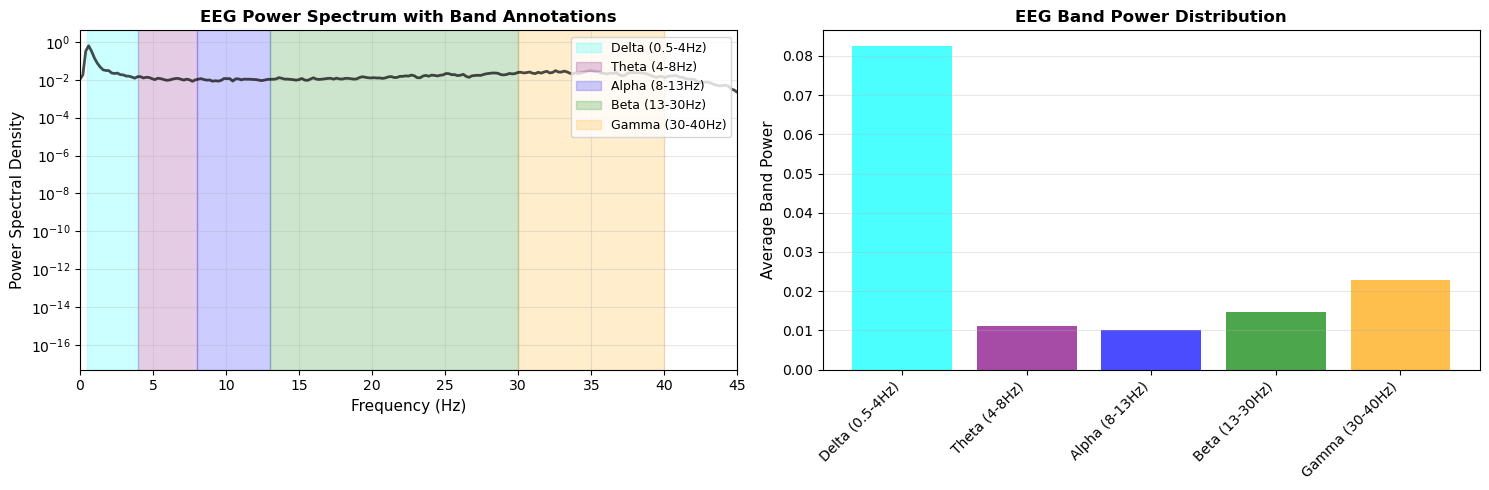


频段能量分析说明:
1. 左图展示了完整的功率谱,彩色区域标注了不同的脑电频段
2. 右图展示了各频段的平均能量对比
3. 不同情绪状态下,各频段的相对能量会有显著差异:
   - Alert状态: β波能量较高
   - Relaxed状态: α波能量较高
   - Nervous状态:  α波能量较低
4. 深度学习模型会自动学习这些频段特征来识别情绪


In [ ]:
# ============================================================================
# 可视化频段能量分布
# ============================================================================

# ----------------------------------------------------------------------------
# 创建1行2列的子图布局
# ----------------------------------------------------------------------------
# subplots(1, 2)：创建1行2列的子图
# figsize=(15, 5)：图形窗口大小
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ============================================================================
# 左图：功率谱图 + 频段标注
# ============================================================================

# 计算处理后信号的完整功率谱
freqs, power = compute_power_spectrum(processed_signal, sampling_rate)

# 使用对数坐标绘制功率谱
ax1.semilogy(
    freqs,              # X轴：频率
    power,              # Y轴：功率谱密度（对数坐标）
    linewidth=2,        # 线条宽度
    color='black',      # 黑色曲线
    alpha=0.7           # 透明度70%
)

# 设置X轴显示范围：0-45Hz（覆盖所有EEG频段）
ax1.set_xlim([0, 45])

# 设置轴标签
ax1.set_xlabel('Frequency (Hz)', fontsize=11)
ax1.set_ylabel('Power Spectral Density', fontsize=11)

# 设置标题
ax1.set_title('EEG Power Spectrum with Band Annotations', fontsize=12, fontweight='bold')

# 显示网格
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# 在频谱图上标注各个频段的位置
# ----------------------------------------------------------------------------
# 为每个频段分配不同的颜色
colors = ['cyan', 'purple', 'blue', 'green', 'orange']

# 遍历所有频段，用彩色阴影标注其在频谱上的位置
for (band_name, band_range), color in zip(bands.items(), colors):
    # axvspan: 绘制垂直跨度（阴影区域）
    ax1.axvspan(
        band_range[0],      # 频段起始频率
        band_range[1],      # 频段结束频率
        alpha=0.2,          # 透明度20%
        color=color,        # 使用指定颜色
        label=band_name     # 图例标签
    )

# 显示图例（位于右上角）
ax1.legend(loc='upper right', fontsize=9)

# ============================================================================
# 右图：各频段能量的柱状图
# ============================================================================

# 提取频段名称和对应的能量值
band_names = list(band_powers.keys())
band_values = list(band_powers.values())

# 绘制柱状图
ax2.bar(
    range(len(band_names)),  # X轴位置：0, 1, 2, 3, 4
    band_values,             # 柱子高度：各频段的能量值
    color=colors,            # 柱子颜色：与左图对应
    alpha=0.7                # 透明度70%
)

# 设置X轴刻度和标签
ax2.set_xticks(range(len(band_names)))  # X轴刻度位置
ax2.set_xticklabels(
    band_names,          # X轴标签：频段名称
    rotation=45,         # 旋转45度，避免重叠
    ha='right'           # 水平对齐方式：右对齐
)

# 设置Y轴标签
ax2.set_ylabel('Average Band Power', fontsize=11)

# 设置标题
ax2.set_title('EEG Band Power Distribution', fontsize=12, fontweight='bold')

# 只在Y轴方向显示网格
ax2.grid(True, alpha=0.3, axis='y')

# 调整布局并显示
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 打印频段能量分析说明
# ----------------------------------------------------------------------------
print("\n频段能量分析说明:")
print("1. 左图展示了完整的功率谱,彩色区域标注了不同的脑电频段")
print("2. 右图展示了各频段的平均能量对比")
print("3. 不同情绪状态下,各频段的相对能量会有显著差异:")
print("   - Alert状态: β波能量较高")
print("   - Relaxed状态: α波能量较高")
print("   - Nervous状态:  α波能量较低")
print("4. 深度学习模型会自动学习这些频段特征来识别情绪")

#### 2.5.1 各脑电频段能量的计算与图表解读

这里对上面的代码和图表做一个更细致的说明，帮助大家理解：

---

##### 1️⃣ 各频段"能量"是怎么计算出来的？

在前一个单元格中，我们使用了函数 `calculate_band_power`：

```python
freqs, power = signal.welch(data, fs=sampling_rate, nperseg=1024)
idx_band = np.logical_and(freqs >= band_range[0], freqs <= band_range[1])
band_power = np.mean(power[idx_band])
```

可以分三步理解：

- **第1步：Welch方法计算功率谱密度 (Power Spectral Density, PSD)**
  - `signal.welch` 会把时域信号分段、对每一段做FFT，再平均，得到一个更平滑、稳定的频谱。
  - 输出：
    - `freqs`：横轴频率点（0Hz ~ 100Hz 左右）
    - `power`：对应每个频率点上的**功率谱密度**（单位功率/Hz，可理解为“在这个频率附近有多强的振荡”）。

- **第2步：选出某个频段内的频率**
  - 例如 α 波段是 8–13Hz：
    - `idx_band` 就是 8–13Hz 之间所有频率点的布尔索引。

- **第3步：对这个频段内的功率取平均**
  - `power[idx_band]`：取出8–13Hz范围内的功率值
  - `np.mean(...)`：算出这些功率的平均值，作为**该频段的平均能量**。

> 小结：**频段能量 = 该频段内所有频率点的功率谱密度的平均值**，反映了这个频段整体的振荡强度。

---

##### 2️⃣ 这些"能量"代表了什么生理含义？

- **Delta (0.5–4Hz)**：慢波成分，和深度睡眠、无意识过程相关；能量高通常表示大脑处于低唤醒状态。
- **Theta (4–8Hz)**：困倦、走神、创造性思维、记忆加工；能量上升常出现在快要打瞌睡或做白日梦时。
- **Alpha (8–13Hz)**：闭眼放松、安静清醒；
  - 闭眼或放松时 α 能量通常升高；
  - 睁眼、做题或紧张时 α 能量会下降。
- **Beta (13–30Hz)**：警觉、专注、逻辑思考；
  - 做题、紧张、压力大时 β 能量通常升高。
- **Gamma (30–40Hz)**：高度认知、整合加工、紧张/焦虑相关的高频活动。

> 因此，**某个频段能量越高，说明这个频段对应的脑部活动越“活跃”**。

---

##### 3️⃣ 右侧柱状图

右图标题为 `EEG Band Power Distribution`：

- 横轴：五个脑电频段（Delta / Theta / Alpha / Beta / Gamma）。
- 纵轴：`Average Band Power`，即刚才计算出的**平均功率**。
- 每一根柱子的高度 = 该频段在当前这段EEG中的平均能量。

**示例：**

- 如果 **Delta** 柱子最高：说明这段信号中慢波成分最强，更偏向“低唤醒 / 困倦 / 深度放松”。
- 如果 **Alpha** 柱子明显偏高：说明被试更接近“闭眼放松、安静清醒”的状态。
- 如果 **Beta / Gamma** 明显偏高：说明高频活动更强，可能处于“高度专注 / 紧张 / 压力大”的状态。

> 注意：这里只是**一段数据的结果**，不能单凭一张图就下“情绪结论”，需要多段数据做统计或交给模型学习。

---

##### 4️⃣ 左侧带彩色区的频谱图怎么看？

左图标题为 `EEG Power Spectrum with Band Annotations`：

- 黑色曲线：完整的功率谱（每个频率点上的功率）。
- 彩色阴影区域：
  - 标出了 Delta / Theta / Alpha / Beta / Gamma 五个频段在频率轴上的位置。
  - 某个彩色区域内曲线越“高”，说明该频段的能量越强。

对比：
- 先看左图：哪一块彩色区域里的曲线更高。
- 再看右图：对应的柱子是不是也更高。

这样就能把**“频谱曲线的形状”**和**“频段能量的柱状图”**联系起来理解。

---

##### 5️⃣ 不同情绪下，如何通过这些图表区分？

从心理与脑电研究的共识来看（这里只讲**趋势**，不是绝对规则）：

- **Alert / 专注做题 / 紧张答题**：
  - β（13–30Hz）和部分 γ（30–40Hz）能量 **相对更高**；
  - α 能量通常 **降低**（因为不再放松）。

- **Relaxed / 放松闭眼 / 冥想**：
  - α（8–13Hz）能量 **明显升高**，是典型“放松”的标志；
  - β、γ 相对较低。

- **Nervous / 焦虑紧张**：
  - β 能量都可能 **偏高**；
  - 有时伴随 θ 变化，取决于个体差异。


### 2.6 项目完整预处理流程总结

现在让我们回顾一下**项目中完整的预处理流程**（与main.py完全对齐）：

In [ ]:
# ============================================================================
# 演示项目完整预处理流程（与main.py中的EEGDataset类完全一致）
# ============================================================================

print("=== 项目完整预处理流程演示 ===\n")

# ============================================================================
# 步骤1: 读取CSV文件
# ============================================================================
# 这一步我们之前已经完成了，这里只是回顾数据的基本信息
print("步骤1: 读取CSV文件")
print(f"   原始数据形状: {eeg_array.shape}")  # (时间点数, 16通道)
print(f"   数据类型: {eeg_array.dtype}")      # 通常是int64

# ============================================================================
# 步骤2: 带通滤波（0.5-40Hz）
# ============================================================================
# 目的：去除基线漂移（<0.5Hz）和高频噪声（>40Hz），保留有用的脑电信号
print("\n步骤2: 带通滤波 (0.5-40Hz)")
full_data = bandpass_filter(
    eeg_array,           # 输入原始数据
    sampling_rate=202,   # 采样率
    lowcut=0.5,          # 低频截止
    highcut=40           # 高频截止
)
print(f"   滤波后形状: {full_data.shape}")

# ============================================================================
# 步骤3: Z-score标准化（逐通道）
# ============================================================================
# 目的：消除不同通道之间的幅度差异，使所有通道的数据具有可比性
# 关键点：对每个通道单独进行标准化
print("\n步骤3: Z-score标准化 (逐通道)")

# 遍历所有16个通道
for i in range(full_data.shape[1]):
    # 计算该通道的均值和标准差
    mean = np.mean(full_data[:, i])
    std = np.std(full_data[:, i])
    
    # 检查标准差是否过小（接近0），避免除以0的错误
    if std > 1e-8:
        # 应用Z-score标准化：(x - mean) / std
        full_data[:, i] = (full_data[:, i] - mean) / std
    else:
        # 如果标准差接近0（信号几乎没有变化），将该通道置为0
        full_data[:, i] = 0.0

# 验证标准化结果（所有通道的整体均值应该接近0，标准差接近1）
print(f"   标准化后 - 均值: {np.mean(full_data):.6f}, 标准差: {np.std(full_data):.6f}")

# ============================================================================
# 步骤4: 裁剪到[-20, 20]范围
# ============================================================================
# 目的：去除极端异常值，提高模型的鲁棒性
# np.clip()将所有值限制在[-20, 20]范围内：
#   - 小于-20的值会被设为-20
#   - 大于20的值会被设为20
#   - 在[-20, 20]范围内的值保持不变
print("\n步骤4: 裁剪到[-20, 20]范围")
full_data = np.clip(full_data, -20.0, 20.0)
print(f"   裁剪后 - 最小值: {np.min(full_data):.2f}, 最大值: {np.max(full_data):.2f}")

# ============================================================================
# 步骤5: 滑动窗口切分
# ============================================================================
# 目的：将长时间序列切分成固定长度的窗口，每个窗口作为一个训练样本
# 
# 参数说明：
#   - window_size = 404: 每个窗口包含404个时间点（约2秒）
#   - stride = 202: 窗口之间的步长为202个点（约1秒），即窗口有50%重叠
print("\n步骤5: 滑动窗口切分")

# 定义窗口参数
window_size = 404  # 窗口大小：404个采样点 ≈ 2秒（404 / 202 ≈ 2）
stride = 202       # 步长：202个采样点 ≈ 1秒，窗口之间有50%重叠

# 存储所有窗口
windows = []
start = 0  # 窗口起始位置

# 使用滑动窗口切分数据
while start + window_size <= len(full_data):
    # 提取一个窗口：从start到start+window_size
    window = full_data[start : start + window_size]
    
    # 将窗口添加到列表中
    windows.append(window)
    
    # 移动到下一个窗口位置
    start += stride

# 打印切分结果
print(f"   从 {len(full_data)} 个时间点生成了 {len(windows)} 个窗口")
print(f"   每个窗口形状: {windows[0].shape if windows else 'N/A'}")  # (404, 16)

# ============================================================================
# 预处理完成
# ============================================================================
print("\n✅ 预处理完成! 数据已准备好用于深度学习模型训练")
print("\n说明:")
print("- 这个流程与 main.py 中的 EEGDataset 类完全一致")
print("- 模型训练时会自动应用这些预处理步骤")
print("- 所有的超参数(滤波频率、窗口大小等)都已经过优化")

=== 项目完整预处理流程演示 ===

步骤1: 读取CSV文件
   原始数据形状: (65852, 16)
   数据类型: int64

步骤2: 带通滤波 (0.5-40Hz)
   滤波后形状: (65852, 16)

步骤3: Z-score标准化 (逐通道)
   标准化后 - 均值: 0.000000, 标准差: 1.000000

步骤4: 裁剪到[-20, 20]范围
   裁剪后 - 最小值: -6.56, 最大值: 12.13

步骤5: 滑动窗口切分
   从 65852 个时间点生成了 325 个窗口
   每个窗口形状: (404, 16)

✅ 预处理完成! 数据已准备好用于深度学习模型训练

说明:
- 这个流程与 main.py 中的 EEGDataset 类完全一致
- 模型训练时会自动应用这些预处理步骤
- 所有的超参数(滤波频率、窗口大小等)都已经过优化


---

## 课程总结
## Module Summary

### 你已经学会了：

**第一部分 - Python数值处理基础:**
1. ✅ 使用Pandas读取CSV格式的EEG数据
2. ✅ NumPy数组的基本操作(切片、统计、标准化)
3. ✅ 使用Matplotlib绘制时域波形
4. ✅ 理解EEG数据的基本结构(时间点 × 通道数)

**第二部分 - EEG信号处理入门:**
1. ✅ 带通滤波器的原理和应用(0.5-40Hz) - **与项目完全一致**
2. ✅ FFT频谱分析的基本方法
3. ✅ 脑电频段(δ、θ、α、β、γ)的定义和能量计算
4. ✅ 完整预处理流程: 滤波 → 标准化 → 裁剪 → 滑动窗口

### 关键收获：
- **数据流程**: CSV文件 → NumPy数组 → 滤波(0.5-40Hz) → Z-score标准化 → 裁剪(-20~20) → 滑动窗口
- **信号质量**: 原始EEG信号需要经过完整的预处理流程才能用于模型训练
- **频域分析**: 频谱图比时域波形更能反映信号的本质特征
- **情绪特征**: 不同情绪状态在脑电频段能量上有显著差异
- **项目对齐**: 所有预处理步骤都与main.py中的深度学习模型训练流程完全一致

### 下一步：
在下一个模块中,我们将学习如何构建深度学习模型(EEGBiFormer),利用这些预处理后的EEG信号进行情绪分类。

---

## 练习任务 
## Practice Tasks (Optional)

1. **更换数据文件**: 尝试读取`dataset/train`文件夹下的其他CSV文件,观察不同情绪状态(Alert/Nervous/Relaxed)的EEG信号差异

2. **对比情绪状态**: 分别分析Alert、Nervous、Relaxed三种状态的数据,对比它们的频段能量分布

先取 **Alert（dataset\test\Quietly_work.csv） / Relaxed （dataset\test\Daily_communication.csv）/ Nervous（dataset\test\Stressful_communication.csv）** 三种标签下的不同时段数据，各自画出频段能量柱状图。
再观察并总结
   - 哪种状态下 **α 柱子最高**？（通常是 Relaxed）
   - 哪种状态下 **β / γ 柱子更突出**？（通常是 Alert 或 Nervous）


---